In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
df = pd.read_csv("dataset_no_show_clinica_care.csv")

Análise de Previsão utilizando Machine Learning (Tema 1)

Previsão de No-Shows (Pacientes que faltam)

- O dataset utilizado é derivado das tabelas relacionais criadas para a primeira etapa do desafio;
- Adicionei mais informações a fim de obter uma análise dos dados mais equilibrada.


## Treinamento e Avaliação do modelo:
- Exploração de dados e filtragem;
- Tabelas e gráficos demonstrativos;
- Definição e configurações do modelo.

In [ ]:
df.head()

,id_consulta,id_paciente,sexo,tipo_plano,idade,especialidade,data_consulta,dias_antecedencia,historico_faltas,valor_consulta,status_consulta
0,1,39,Masculino,Bradesco Saúde,31,Cardiologia,2026-01-05,18,0,300.0,Realizada
1,2,29,Feminino,Unimed,48,Oftalmologia,2026-01-07,19,0,230.0,Realizada
2,3,15,Feminino,SulAmérica,75,Ginecologia,2026-01-09,5,0,260.0,Faltou
3,4,43,Feminino,Bradesco Saúde,22,Neurologia,2026-01-11,15,1,320.0,Realizada
4,5,8,Masculino,Particular,52,Oftalmologia,2026-01-13,25,0,230.0,Realizada


In [ ]:
df.shape

(150, 11)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id_consulta        150 non-null    int64  
 1   id_paciente        150 non-null    int64  
 2   sexo               150 non-null    object 
 3   tipo_plano         150 non-null    object 
 4   idade              150 non-null    int64  
 5   especialidade      150 non-null    object 
 6   data_consulta      150 non-null    object 
 7   dias_antecedencia  150 non-null    int64  
 8   historico_faltas   150 non-null    int64  
 9   valor_consulta     150 non-null    float64
 10  status_consulta    150 non-null    object 
dtypes: float64(1), int64(5), object(5)
memory usage: 13.0+ KB


In [ ]:
df.isnull().sum()

,0
id_consulta,0
id_paciente,0
sexo,0
tipo_plano,0
idade,0
especialidade,0
data_consulta,0
dias_antecedencia,0
historico_faltas,0
valor_consulta,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df["data_consulta"] = pd.to_datetime(df["data_consulta"])
df.dtypes

,0
id_consulta,int64
id_paciente,int64
sexo,object
tipo_plano,object
idade,int64
especialidade,object
data_consulta,datetime64[ns]
dias_antecedencia,int64
historico_faltas,int64
valor_consulta,float64


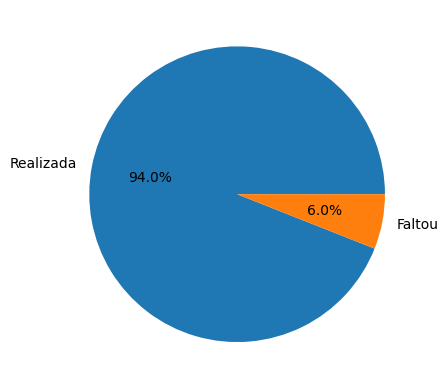

In [ ]:
from enum import auto
df["status_consulta"].value_counts() # status da consulta: se foi realizada ou não na clínica e criação do gráfico
plt.pie(df["status_consulta"].value_counts(), labels=df["status_consulta"].value_counts().index, autopct="%1.1f%%")
plt.show()

In [ ]:
df.groupby("especialidade")["status_consulta"].value_counts() # tabela de especialidade e o status da consulta: realizada ou em falta.

especialidade      status_consulta
Cardiologia        Realizada          15
                   Faltou              1
Clinica Geral      Realizada          12
                   Faltou              2
Dermatologia       Realizada           8
Endocrinologia     Realizada           7
                   Faltou              1
Gastroenterologia  Realizada          17
                   Faltou              1
Ginecologia        Realizada          17
                   Faltou              1
Neurologia         Realizada           4
Oftalmologia       Realizada          15
Ortopedia          Realizada          14
                   Faltou              1
Pediatria          Realizada          16
Psiquiatria        Realizada          11
                   Faltou              1
Urologia           Realizada           5
                   Faltou              1
Name: count, dtype: int64

In [ ]:
no_shows = df[df["status_consulta"] == "Faltou"]
no_shows_for_especialidade = no_shows["especialidade"].value_counts() #tabela de contagem por especialidade em número dos que não foram à consulta.
no_shows_for_especialidade

,count
especialidade,
Clinica Geral,2
Ginecologia,1
Urologia,1
Gastroenterologia,1
Psiquiatria,1
Endocrinologia,1
Cardiologia,1
Ortopedia,1


In [ ]:
total_por_especialidade = df["especialidade"].value_counts()
total_por_especialidade

,count
especialidade,
Ginecologia,18
Gastroenterologia,18
Pediatria,16
Cardiologia,16
Ortopedia,15
Oftalmologia,15
Clinica Geral,14
Psiquiatria,12
Endocrinologia,8


In [ ]:
taxa_no_show = (no_shows_for_especialidade /total_por_especialidade)*100
taxa_no_show = taxa_no_show.fillna(0) #taxa de no show por especialidade a partir de 0.
taxa_no_show

,count
especialidade,
Cardiologia,6.250000
Clinica Geral,14.285714
Dermatologia,0.000000
Endocrinologia,12.500000
Gastroenterologia,5.555556
Ginecologia,5.555556
Neurologia,0.000000
Oftalmologia,0.000000
Ortopedia,6.666667


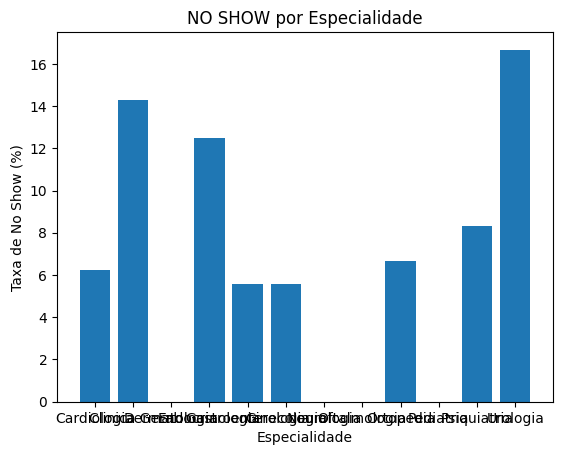

In [ ]:
plt.bar(taxa_no_show.index, taxa_no_show.values) # gráfico de barra (no_show) por especialidade de cada médico...
plt.title("NO SHOW por Especialidade")
plt.xlabel("Especialidade")
plt.ylabel("Taxa de No Show (%)")
plt.show()

In [ ]:
df["mes"] = df["data_consulta"].dt.to_period("M") #contagem de consulta por cada mês
df["mes"].value_counts().sort_index()

,count
mes,
2026-01,14
2026-02,14
2026-03,15
2026-04,15
2026-05,16
2026-06,15
2026-07,15
2026-08,16
2026-09,15


In [ ]:
no_shows = df[df["status_consulta"] == "Faltou"]
no_shows_por_mes = no_shows["mes"].value_counts().sort_index() # quantidade de faltas por mês em consultas...
no_shows_por_mes


,count
mes,
2026-01,3
2026-05,1
2026-06,1
2026-07,3
2026-09,1


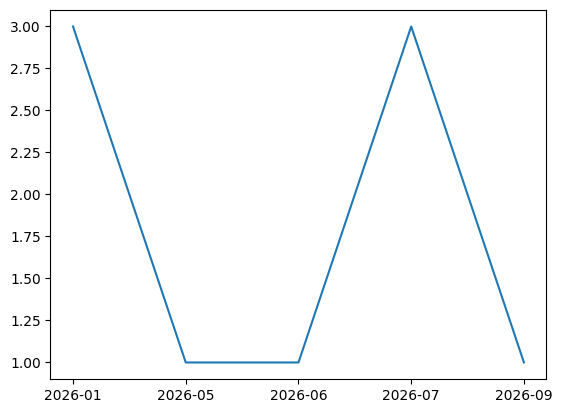

In [ ]:
meses = no_shows_por_mes.index.astype(str) #grafico de linha de NO SHOWS segundo cada mês...
plt.plot(meses, no_shows_por_mes.values)
plt.show()

In [ ]:
media_antecedencia = np.mean(df["dias_antecedencia"]) #media de antecedência...
media_antecedencia


np.float64(15.14)

In [ ]:
desvio_antecedencia = np.std(df["dias_antecedencia"]) # desvio padrão de antecedência...
desvio_antecedencia


8.894964867833936

In [ ]:
y = df["status_consulta"] #target
y

,status_consulta
0,Realizada
1,Realizada
2,Faltou
3,Realizada
4,Realizada
...,...
145,Realizada
146,Realizada
147,Realizada
148,Realizada


In [ ]:
x = df[["sexo", "tipo_plano", "idade", "especialidade", "dias_antecedencia", "historico_faltas", "valor_consulta"]] #features
x

,sexo,tipo_plano,idade,especialidade,dias_antecedencia,historico_faltas,valor_consulta
0,Masculino,Bradesco Saúde,31,Cardiologia,18,0,300.0
1,Feminino,Unimed,48,Oftalmologia,19,0,230.0
2,Feminino,SulAmérica,75,Ginecologia,5,0,260.0
3,Feminino,Bradesco Saúde,22,Neurologia,15,1,320.0
4,Masculino,Particular,52,Oftalmologia,25,0,230.0
...,...,...,...,...,...,...,...
145,Feminino,Bradesco Saúde,46,Oftalmologia,11,0,230.0
146,Masculino,Unimed,30,Ginecologia,19,1,260.0
147,Feminino,Unimed,63,Gastroenterologia,15,1,270.0
148,Feminino,Unimed,52,Gastroenterologia,25,1,270.0


In [ ]:
encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

In [ ]:
colunas_categoricas =["sexo", "tipo_plano", "especialidade"]
colunas_numericas = ["idade","dias_antecedencia", "historico_faltas","valor_consulta"]

preprocessor = ColumnTransformer(
    transformers=[
        ("categoricas", encoder, colunas_categoricas),
        ("numericas", StandardScaler(), colunas_numericas)
    ]
)

In [ ]:
X_treino, X_teste, y_treino, y_teste = train_test_split(
    x, y, test_size=0.2, random_state=42
)

In [ ]:
modelo = DecisionTreeClassifier(random_state=42)

In [ ]:
pipeline = Pipeline([ # preparação dos dados com pipeline
    ("preprocessamento", preprocessor),
    ("modelo", modelo)
])

In [ ]:
pipeline.fit(X_treino, y_treino) #junção de feature e target para relação e amostra da estrutura padrão

Pipeline(steps=[('preprocessamento',
                 ColumnTransformer(transformers=[('categoricas',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['sexo', 'tipo_plano',
                                                   'especialidade']),
                                                 ('numericas', StandardScaler(),
                                                  ['idade', 'dias_antecedencia',
                                                   'historico_faltas',
                                                   'valor_consulta'])])),
                ('modelo', DecisionTreeClassifier(random_state=42))])

In [ ]:
previsoes = pipeline.predict(X_teste) #previsão de teste

In [ ]:
acuracia = accuracy_score(y_teste, previsoes) #acuracia da maquina
acuracia

0.8333333333333334

In [ ]:
matriz = confusion_matrix(y_teste, previsoes)
matriz

array([[ 0,  3],
       [ 2, 25]])

In [ ]:
print(classification_report(y_teste, previsoes))

              precision    recall  f1-score   support

      Faltou       0.00      0.00      0.00         3
   Realizada       0.89      0.93      0.91        27

    accuracy                           0.83        30
   macro avg       0.45      0.46      0.45        30
weighted avg       0.80      0.83      0.82        30



## 2º Modelo de Máquina:

In [ ]:
modelo_balanceado = DecisionTreeClassifier(
    random_state=42,
    class_weight="balanced"
)

In [ ]:
pipeline_balanceado = Pipeline ([
    ("preprocessamento", preprocessor),
    ("modelo", modelo_balanceado)
])

In [ ]:
pipeline_balanceado.fit (X_treino, y_treino)

Pipeline(steps=[('preprocessamento',
                 ColumnTransformer(transformers=[('categoricas',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['sexo', 'tipo_plano',
                                                   'especialidade']),
                                                 ('numericas', StandardScaler(),
                                                  ['idade', 'dias_antecedencia',
                                                   'historico_faltas',
                                                   'valor_consulta'])])),
                ('modelo',
                 DecisionTreeClassifier(class_weight='balanced',
                                        random_state=42))])

In [ ]:
previsoes_balanceado = pipeline_balanceado.predict(X_teste)

In [ ]:
accuracy_score(y_teste, previsoes_balanceado)

0.9

In [ ]:
print(classification_report(y_teste, previsoes_balanceado)) # amostra das previsoes da segunda máquina

              precision    recall  f1-score   support

      Faltou       0.00      0.00      0.00         3
   Realizada       0.90      1.00      0.95        27

    accuracy                           0.90        30
   macro avg       0.45      0.50      0.47        30
weighted avg       0.81      0.90      0.85        30



/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
resultado = pd.DataFrame({
    "Real": y_teste,
    "Previsto": previsoes_balanceado
})

resultado

,Real,Previsto
73,Realizada,Realizada
18,Realizada,Realizada
118,Realizada,Realizada
78,Realizada,Realizada
76,Faltou,Realizada
31,Realizada,Realizada
64,Faltou,Realizada
141,Realizada,Realizada
68,Realizada,Realizada
82,Realizada,Realizada


## **Conclusão da Análise de Previsão: Tema 1 (Previsão de NO SHOWS, Pacientes que faltam):**

Em conclusão ao processo de análise de previsão, subi o dataset da Clinica com o objetivo de filtrar dentre os dados os pacientes que faltaram as consultas; e no processo de levantamento e desenvolvimento, observei que por mais que o indice de acurácia fosse (83,3%), as previsões que tem como tema do projeto não foram correspondentes, embora tenha acertado a grande maioria das consultas "Realizadas". Desenvolvi uma segunda versão do modelo, balanceando a questão da filtragem e questões relacionadas às features, mas mesmo tendo atingido um indice maior que a primeira máquina (90%), a principal questão que envolvia os faltosos da Clinica também não foram correspondentes, concluindo que ambos os modelos não conseguiram  identificar os casos de no-show. Apesar disso, todos os processos foram concluídos com êxito em todas as etapas propostas, gerando insights sobre o sistema de funcionamento da clinica através da aplicação de Machine Learning.